In [1]:
import pandas as pd
import numpy as np
import duckdb
import polars as pl
import pyarrow as pa


print("Pandas :", pd.__version__)
print("NumPy :", np.__version__)
print("DuckDB", duckdb.__version__)
print("Polars:",pl.__version__)
print("PyArrow", pa.__version__)

df = pd.DataFrame({
    "produit":["Canapé","Lampe", "Table"],
    "ca":[799,49,399],
    "cout":[420,18,210]
})

df["marge"] = df["ca"]-df["cout"]

df

Pandas : 3.0.6
NumPy : 2.4.6
DuckDB 1.5.5
Polars: 1.44.2
PyArrow 25.0.1


,produit,ca,cout,marge
0,Canapé,799,420,379
1,Lampe,49,18,31
2,Table,399,210,189


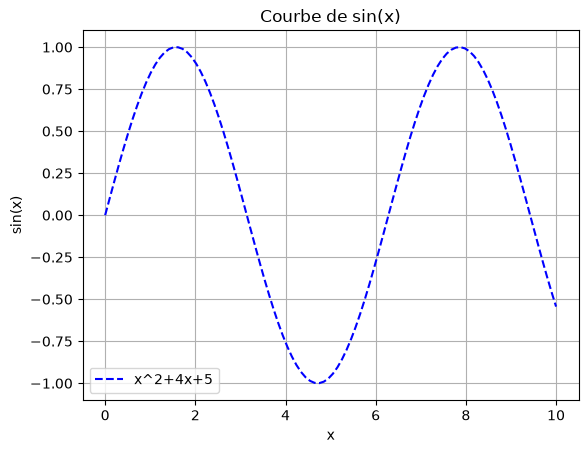

In [4]:
import matplotlib.pyplot as plt
import numpy as np

# Données
x = np.linspace(0, 10, 100)
y = np.sin(x)

# Créer un graphique
plt.plot(x, y, label="x^2+4x+5", color="blue", linestyle="--")
plt.title("Courbe de sin(x)")
plt.xlabel("x")
plt.ylabel("sin(x)")
plt.legend()
plt.grid(True)
plt.show()

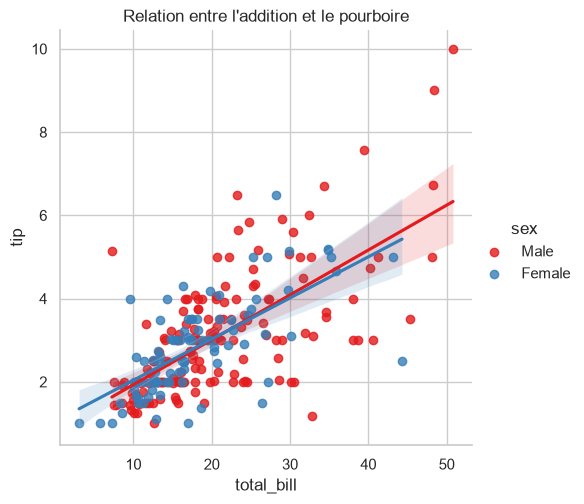

In [6]:
import seaborn as sns
import numpy as np

# Données
tips = sns.load_dataset("tips")

# Nuage de points avec régression
sns.lmplot(x="total_bill", y="tip", data=tips, hue="sex", palette="Set1")
plt.title("Relation entre l'addition et le pourboire")
plt.show()

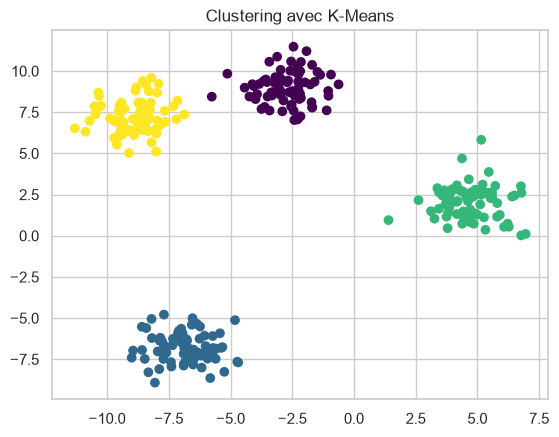

In [10]:
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs
import matplotlib.pyplot as plt

# Générer des données artificielles
X, _ = make_blobs(n_samples=300, centers=4, random_state=42)

# Créer et entraîner un modèle K-Means
kmeans = KMeans(n_clusters=4, random_state=42)
kmeans.fit(X)
y_pred = kmeans.predict(X)

# Visualiser les clusters
plt.scatter(X[:, 0], X[:, 1], c=y_pred, cmap="viridis")
plt.title("Clustering avec K-Means")
plt.show()

In [11]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
import pandas as pd

# Exemple de DataFrame
data = pd.DataFrame({
    "age": [25, 30, 35, 40],
    "income": [50000, 60000, 70000, 80000],
    "city": ["Paris", "Lyon", "Marseille", "Paris"]
})

# Séparer features et target
X = data[["age", "income", "city"]]

# Définir les transformations
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), ["age", "income"]),  # Normaliser les colonnes numériques
        ("cat", OneHotEncoder(), ["city"])  # Encoder les colonnes catégorielles
    ]
)

# Appliquer les transformations
X_transformed = preprocessor.fit_transform(X)
print(X_transformed)

[[-1.34164079 -1.34164079  0.          0.          1.        ]
 [-0.4472136  -0.4472136   1.          0.          0.        ]
 [ 0.4472136   0.4472136   0.          1.          0.        ]
 [ 1.34164079  1.34164079  0.          0.          1.        ]]


In [13]:
import duckdb
df = pd.DataFrame({
    "produit":["Canapé","Lampe", "Table"],
    "ca":[799,49,399],
    "cout":[420,18,210]
})

result = duckdb.sql("""
    SELECT produit, ca, cout, ca - cout as marge
    FROM df
    ORDER BY marge DESC
    """)

result

┌─────────┬───────┬───────┬───────┐
│ produit │  ca   │ cout  │ marge │
│ varchar │ int64 │ int64 │ int64 │
├─────────┼───────┼───────┼───────┤
│ Canapé  │   799 │   420 │   379 │
│ Table   │   399 │   210 │   189 │
│ Lampe   │    49 │    18 │    31 │
└─────────┴───────┴───────┴───────┘